# 08. Time Series Analysis
This notebook covers time series data manipulation and analysis.

## What You'll Learn

- Creating and manipulating TimeSeries objects
- Smoothing techniques (moving average, exponential, Gaussian)
- Block operations (annual max, monthly mean)
- Interpolation and resampling
- Trend analysis
- Seasonal decomposition
- Working with hydrologic data

## Real-World Applications

Streamflow analysis, climate data, water quality monitoring.

## Set Up

In [ ]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta
from System import DateTime, Double, Array
from System.Collections.Generic import List

# Load Numerics DLL
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

from Numerics.Data import TimeSeries,  TimeInterval, BlockFunctionType,TimeSeriesDownload
from helper_functions import convert_to_dotnet_array

print("✓ Setup complete")

✓ Setup complete


## Helper Functions
We define some helper functions to switch between .NET, Python, and TimeSeries objects.

In [3]:
def ts_to_arrays(ts):
    dates = [o.Index for o in ts]
    values = [o.Value for o in ts]
    return np.array(dates), np.array(values)


## 1. Creating TimeSeries Objects
We will construct a regular daily time series and inspect its basic statistical properties.

In [ ]:
np.random.seed(42)

start = DateTime(2020, 1, 1)
values = np.linspace(1, 10, 40)
values_net = convert_to_dotnet_array(values.tolist())

ts = TimeSeries(TimeInterval.OneDay, start, values_net)

dates, vals = ts_to_arrays(ts)

print(f"Sample Size: {len(ts)}")
print(f"Start Date:  {ts.StartDate}")
print(f"End Date:    {ts.EndDate}")
print(f"Mean:        {vals.mean():.2f}")

Sample Size: 40
Start Date:  1/1/2020 12:00:00 AM
End Date:    2/9/2020 12:00:00 AM
Mean:        5.50


## 2. Smoothing
We will explore 2 ways we can smooth noisy data
1. **Moving Average:** Apply a rolling mean to reduce high-frequency variability while preserving trend.
2. **Moving Sum:** Compute rolling accumulation over a fixed window, useful for volume-based metrics.

In [45]:
ma = ts.MovingAverage(period=3)
ma_dates, ma_vals = ts_to_arrays(ma)

print(f"Original Mean: {vals.mean():.2f}")
print(f"Smoothed Mean: {ma_vals.mean():.2f}")
print(f"First MA Val:  {ma_vals[0]:.2f}")

ms = ts.MovingSum(period=3)
_, ms_vals = ts_to_arrays(ms)

print(f"First Moving Sum: {ms_vals[0]:.2f}")


Original Mean: nan
Smoothed Mean: 189555.41
First MA Val:  26666.67
First Moving Sum: 80000.00


## 3. Block Operations

Aggregate high-resolution data into calendar-aligned blocks using reduction operators.
1. **Annual Maximums:** Extract annual peak flows for flood frequency analysis.
2. **Monthly Maximums:** Calculate monthly average flows.


In [ ]:
start = DateTime(2019, 1, 1)
values = np.random.gamma(shape=2.0, scale=3.0, size=730)
value_net = convert_to_dotnet_array(values.tolist())

daily = TimeSeries(TimeInterval.OneDay, start, values_net)

annual_max = daily.CalendarYearSeries(blockFunction=BlockFunctionType.Maximum)
_, annual_vals = ts_to_arrays(annual_max)

monthly_max = ts.MonthlySeries(BlockFunctionType.Maximum)
_, mm_vals = ts_to_arrays(monthly_max)

print(f"Years:        {len(annual_vals)}")
print(f"Annual Maxes: {annual_vals}")
print(f"Months:       {len(mm_vals)}")
print(f"Monthly Peaks: {mm_vals}")


Years:        1
Annual Maxes: [10.]
Months:       1970
Monthly Peaks: [ 41400. 170000. 257000. ...  88000. 134000.  87100.]


## 4. Interpolation
Interpolate short gaps in the time series while preserving surrounding trends.

In [7]:
gap_values = values.copy()
gap_values[10:15] = np.nan
gap_values_net = convert_to_dotnet_array(gap_values.tolist())

ts_gap = TimeSeries(TimeInterval.OneDay, start, gap_values_net)

missing_before = sum(np.isnan(o.Value) for o in ts_gap)
ts_gap.InterpolateMissingData(maxNumberOfMissing=10)
missing_after = sum(np.isnan(o.Value) for o in ts_gap)

print(f"Missing before: {missing_before}")
print(f"Missing after:  {missing_after}")


Missing before: 5
Missing after:  0


## 5. Resampling

In [8]:
hourly = daily.ConvertTimeInterval(
    TimeInterval.OneHour,
    average= True
)


_, hourly_vals = ts_to_arrays(hourly)

print(f"Hourly Count: {len(hourly_vals)}")
print(f"Hourly Mean:  {hourly_vals.mean():.2f}")

# COME BACK AND SEE IF WE CAN GO FROM DAILY TO MONTHLY

Hourly Count: 937
Hourly Mean:  5.50


## 6. USGS Data Download Integration
Download observed streamflow data and apply immediate statistical analysis.

In [ ]:
# USGS site number for Mississippi River at St. Louis, MO
site = "07010000"

if TimeSeriesDownload.IsConnectedToInternet:
    task = TimeSeriesDownload.FromUSGS("07010000")
    result = task.Result
    ts = result.Item1
    raw = result.Item2
else:
    ts = None

_, q_vals = ts_to_arrays(ts)

# Get rid of NaN values
valid = q_vals[~np.isnan(q_vals)]

print(f"USGS Sample Size: {len(q_vals)}")
print(f"Valid Samples:    {len(valid)}")
print(f"Mean Flow:        {np.mean(valid):.2f}")
print(f"Peak Flow:        {np.max(valid):.2f}")


monthly_max = ts.MonthlySeries(BlockFunctionType.Maximum)
mm_dates, mm_vals = ts_to_arrays(monthly_max)

print(f"Monthly Peaks: {mm_vals}")


USGS Sample Size: 60300
Valid Samples:    59933
Mean Flow:        190711.64
Peak Flow:        1050000.00
Monthly Peaks: [ 41400. 170000. 257000. ...  88000. 134000.  87100.]


## 7. Plotting Time Series

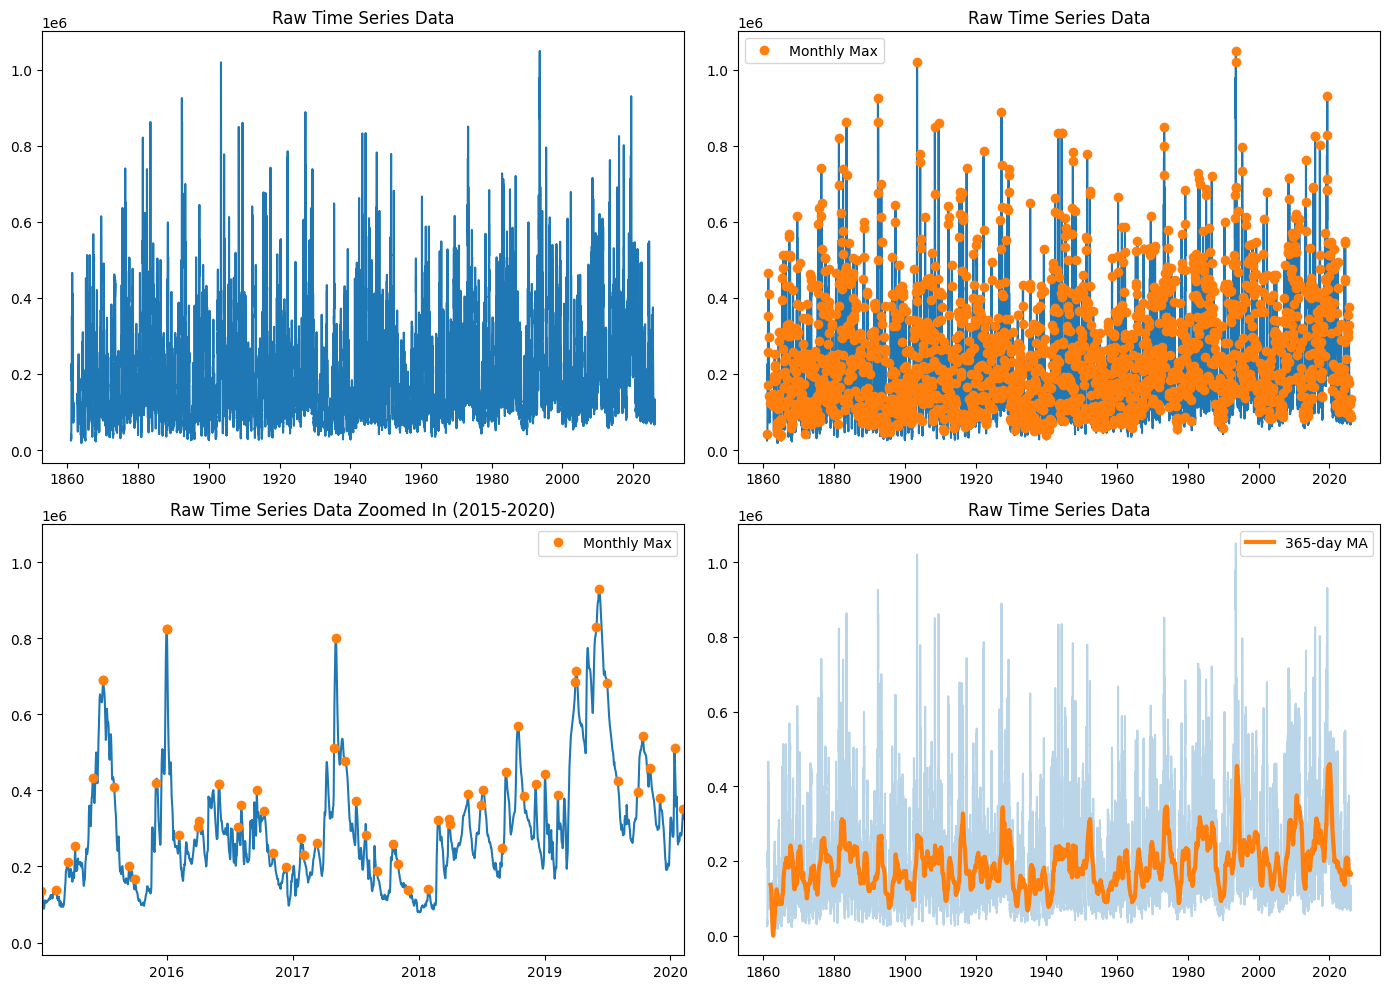

In [ ]:
# Raw data
dates, vals = ts_to_arrays(ts)
# Convert .NET DateTime to Python datetime
py_dates = [datetime(o.Year, o.Month, o.Day, o.Hour, o.Minute, o.Second) for o in dates]

py_mm_dates = [datetime(o.Year, o.Month, o.Day, o.Hour, o.Minute, o.Second) for o in mm_dates]


ma = ts.MovingAverage(period=365)

# Moving average
ma_dates, ma_vals = ts_to_arrays(ma)
# Convert .NET DateTime to Python datetime
py_ma_dates = [datetime(o.Year, o.Month, o.Day, o.Hour, o.Minute, o.Second) for o in ma_dates]  

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(py_dates, vals)
axes[0,0].set_title("Raw Time Series Data")

plt.sca(axes[0,1])
axes[0,1].plot(py_dates, vals)
axes[0,1].plot(py_mm_dates, mm_vals, "o", label="Monthly Max")
axes[0,1].set_title("Raw Time Series Data")
axes[0,1].legend()

plt.sca(axes[1,0])
axes[1,0].plot(py_dates, vals)
axes[1,0].plot(py_mm_dates, mm_vals, "o", label="Monthly Max")
axes[1,0].set_title("Raw Time Series Data Zoomed In (2015-2020)")
axes[1,0].set_xlim([datetime(2015,1,3), datetime(2020,2,9)])
axes[1,0].legend()

plt.sca(axes[1,1])
axes[1,1].plot(py_dates, vals, alpha=0.3)
axes[1,1].plot(py_ma_dates, ma_vals, linewidth=3, label ="365-day MA")
axes[1,1].set_title("Raw Time Series Data")
axes[1,1].legend()

plt.tight_layout()
plt.show()


# Summary

You've learned:
- Creating and manipulating TimeSeries objects
- Smoothing: moving average, moving sum
- Block operations: annual max, monthly means
- Interpolation
- Resampling
- USGS Data Integration
- Plotting TimeSeries data

## Key Takeaways

1. **Smoothing reduces noise** - Choose window based on application
2. **Block operations summarize** - Annual max for floods, monthly means for patterns
3. **Interpolation fills gaps** - Use appropriate method for data type
4. **Resampling:**

## Next Steps

- **02_distribution_fitting.ipynb** - Fit distributions to annual max series
- **07_statistics.ipynb** - Statistical tests on time series

## Exercise

1. Create a time series with seasonal pattern
2. Apply 3 different smoothing methods
3. Extract annual maximums
5. Which method best captures the signal?